# 05  ·  EEGNet

The compact convolutional baseline (Lawhern et al. 2018). About 2,400
parameters total. CPU-trainable in seconds.

The architecture is engineered to do, end-to-end, exactly what FBCSP does
in pieces: temporal filtering (Conv2d temporal kernels), spatial filtering
(depthwise channel-conv per temporal kernel), feature integration
(separable conv), linear decision (linear head).

This notebook trains EEGNet on motor imagery, plots the loss curves, and
visualises the first-layer temporal kernels in time and frequency.

In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


In [2]:
import time
import numpy as np, matplotlib.pyplot as plt
from eeg_cognitive import (make_motor_imagery_synthetic, preprocess_epochs,
                          ChannelStandardizer, cross_validate)
from eeg_cognitive.models import EEGNetClassifier

# Smaller dataset for the notebook so it executes quickly; the headline
# numbers in the report use a larger dataset.
ds = make_motor_imagery_synthetic(n_subjects=2, trials_per_class=14,
                                  snr_db=-12, seed=0)
X = preprocess_epochs(ds.X, ds.sfreq)
print(f"X = {X.shape}")


X = (112, 22, 500)


## Train one model and look at the loss curves

In [3]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(ds.y))
tr, te = perm[: int(len(ds.y)*0.8)], perm[int(len(ds.y)*0.8):]

sc = ChannelStandardizer().fit(X[tr])
Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])

t0 = time.time()
clf = EEGNetClassifier(epochs=30, batch_size=64, lr=1.5e-3, weight_decay=1e-4,
                       patience=12, val_frac=0.2, verbose=False, seed=0)
clf.sfreq = ds.sfreq
clf.eegnet_kernel_length = max(16, int(ds.sfreq // 4))
clf.fit(Xtr, ds.y[tr])
print(f"trained in {time.time()-t0:.1f}s")
print(f"params = {sum(p.numel() for p in clf.model_.parameters())}")
print(f"val acc on the model's internal split: {clf.history_['val_acc'][-1]*100:.1f}%")
print(f"held-out acc: {(clf.predict(Xte) == ds.y[te]).mean()*100:.1f}%")


trained in 2.3s
params = 2404
val acc on the model's internal split: 17.6%
held-out acc: 21.7%


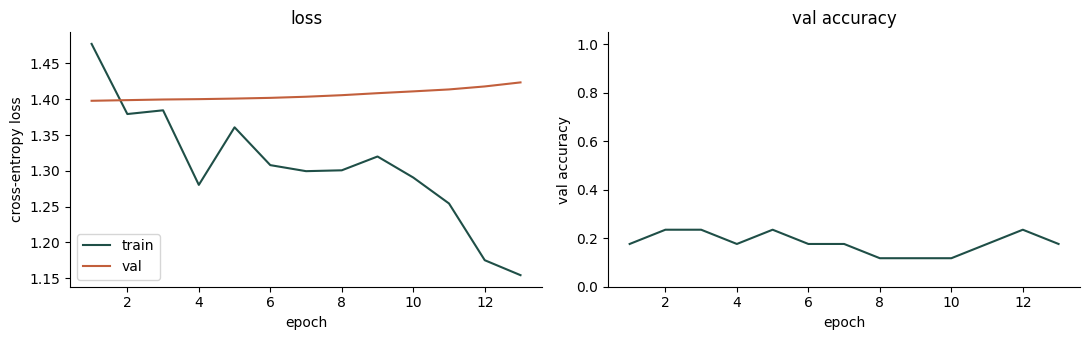

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
h = clf.history_
ep = np.arange(1, len(h['train_loss'])+1)
ax[0].plot(ep, h['train_loss'], label='train', color='#1F4F47')
ax[0].plot(ep, h['val_loss'], label='val', color='#C25F3C')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('cross-entropy loss'); ax[0].set_title('loss')
ax[0].legend(); ax[0].spines['top'].set_visible(False); ax[0].spines['right'].set_visible(False)

ax[1].plot(ep, h['val_acc'], color='#1F4F47')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val accuracy'); ax[1].set_title('val accuracy')
ax[1].set_ylim(0, 1.05)
ax[1].spines['top'].set_visible(False); ax[1].spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


## 3-fold CV (kept short for fast notebook execution)

In [5]:
def make_eegnet():
    c = EEGNetClassifier(epochs=20, batch_size=64, lr=1.5e-3,
                         weight_decay=1e-4, patience=8, val_frac=0.2, seed=0)
    c.sfreq = ds.sfreq
    c.eegnet_kernel_length = max(16, int(ds.sfreq // 4))
    return c

t0 = time.time()
res = cross_validate(X, ds.y, ds.sfreq, clf_factory=make_eegnet,
                     n_splits=3, seed=0, standardize=True)
print(f"EEGNet  ·  motor imagery  ·  {time.time()-t0:.1f}s")
s = res.summary()
print(f"  acc       = {s['acc_mean']*100:5.1f} ± {s['acc_std']*100:4.1f} %")
print(f"  macro-F1  = {s['f1_mean']*100:5.1f} ± {s['f1_std']*100:4.1f}")
print(f"  Cohen's κ = {s['kappa_mean']:+.3f} ± {s['kappa_std']:.3f}")
print(f"  per-fold:   {[f'{a*100:.1f}%' for a in res.accuracy]}")


EEGNet  ·  motor imagery  ·  2.4s
  acc       =  27.7 ±  5.6 %
  macro-F1  =  24.8 ±  6.6
  Cohen's κ = +0.035 ± 0.073
  per-fold:   ['26.3%', '35.1%', '21.6%']


## What did the first layer learn?

Plot each of the 8 temporal kernels in the time domain (top row) and in
the spectral domain (bottom row). Several should peak in the mu (8–13 Hz)
or beta (13–30 Hz) range — the same band FBCSP encodes by hand.

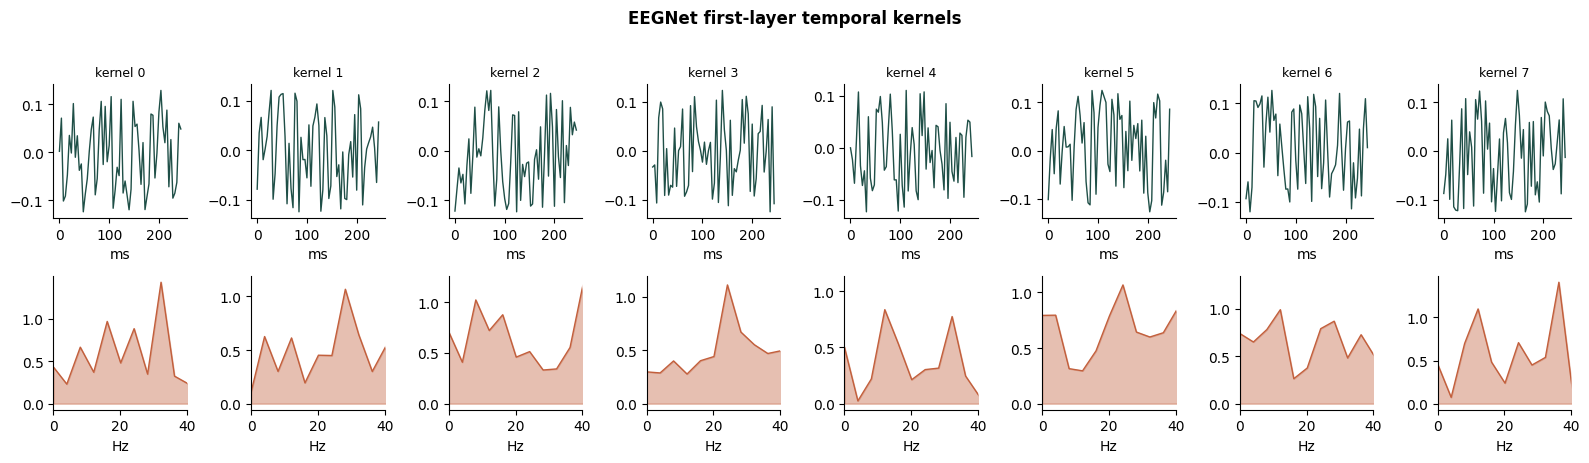

In [6]:
W = clf.model_.conv1.weight.detach().cpu().numpy().squeeze()
n_filters, kl = W.shape

fig, axes = plt.subplots(2, n_filters, figsize=(2.0*n_filters, 4.5))
for i in range(n_filters):
    axes[0, i].plot(np.arange(kl)/ds.sfreq*1000, W[i], color='#1F4F47', lw=1)
    axes[0, i].set_title(f'kernel {i}', fontsize=9)
    axes[0, i].set_xlabel('ms')
    F = np.abs(np.fft.rfft(W[i]))
    freqs = np.fft.rfftfreq(kl, d=1.0/ds.sfreq)
    axes[1, i].fill_between(freqs, F, color='#C25F3C', alpha=0.4)
    axes[1, i].plot(freqs, F, color='#C25F3C', lw=1)
    axes[1, i].set_xlim(0, 40); axes[1, i].set_xlabel('Hz')
for ax in axes.ravel():
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle('EEGNet first-layer temporal kernels', y=1.02, fontweight='bold')
plt.tight_layout(); plt.show()
